# 使用完全連接層估算簡單線性迴歸的參數w、b

In [1]:
# 載入套件
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from sklearn.linear_model import LinearRegression

## 產生隨機資料

In [2]:
# 產生線性隨機資料100筆，介於 0-50
n = 100
X = np.linspace(0, 50, n)
y = np.linspace(0, 50, n)

# 資料加一點雜訊(noise)
X += np.random.uniform(-10, 10, n)
y += np.random.uniform(-10, 10, n)

## 定義模型

In [ ]:
# 定義模型
def create_model(input_feature: int, output_feature: int):
    model = nn.Sequential(
        nn.Linear(input_feature, output_feature),
        nn.Flatten(0, -1), # 所有維度轉成一維 
    )
    return model

In [4]:
# 測試扁平層(Flatten)
input = torch.randn(32, 1, 5, 5)
m = nn.Sequential(
    nn.Conv2d(1, 32, 5, 1, 1),
    nn.Flatten(),
)
output: torch.Tensor = m(input)
output.size()

torch.Size([32, 288])

## 定義訓練函數

In [ ]:
def train(
    X: torch.Tensor,
    y: torch.Tensor,
    epochs: int = 2_000,
    lr: float = 1e-6,
):
    model = create_model(1, 1)

    # 定義損失函數
    loss_fn = nn.MSELoss(reduction='sum')

    loss_list: list[float] = []
    w_list: list[float] = []
    b_list: list[float] = []
    for epoch in range(epochs):  # 執行訓練週期
        y_pred: torch.Tensor = model(X)  # 預測值

        # 計算損失函數值
        # print(y_pred.shape, y.shape)
        MSE = loss_fn.forward(y_pred, y)

        # 梯度重置：改由model.zero_grad() 取代 w、b 逐一設定。
        model.zero_grad()

        # 反向傳導
        MSE.backward()

        # 權重更新：改用 model.parameters 取代 w、b 逐一更新
        with torch.no_grad():
            for param in model.parameters():
                assert param.grad is not None
                param -= lr * param.grad

        # 記錄訓練結果
        linear_layer = cast(nn.Linear, model[0])
        if (epoch + 1) % 1000 == 0 or epochs < 1000:
            w_list.append(linear_layer.weight[:, 0].item())  # w.item()：轉成常數
            b_list.append(linear_layer.bias.item())
            loss_list.append(MSE.item())

    return w_list, b_list, loss_list

## 執行訓練

In [6]:
# 執行訓練
X2, y2 = torch.FloatTensor(X.reshape(X.shape[0], 1)), torch.FloatTensor(y)
w_list, b_list, loss_list = train(X2, y2)

# 取得 w、b 的最佳解
print(f'w={w_list[-1]}, b={b_list[-1]}')

w=0.9379326105117798, b=0.25510716438293457


In [7]:
# 使用不同學習率及更多的執行週期訓練
X2, y2 = torch.FloatTensor(X.reshape(X.shape[0], 1)), torch.FloatTensor(y)
w_list, b_list, loss_list = train(X2, y2, epochs=10**5, lr=1e-5)

# 取得 w、b 的最佳解
print(f'w={w_list[-1]}, b={b_list[-1]}')

w=0.8573277592658997, b=3.0909059047698975


In [8]:
# 執行訓練
coef = np.polyfit(X, y, deg=1)

# 取得 w、b 的最佳解
print(f'w={coef[0]}, b={coef[1]}')

w=0.8573217345919298, b=3.0911169358334987


In [9]:
X2 = X.reshape(X.shape[0], 1)

lr = LinearRegression()
lr.fit(X2, y)

lr.coef_[0], lr.intercept_

(np.float64(0.85732173459193), np.float64(3.0911169358335115))

## 顯示迴歸線

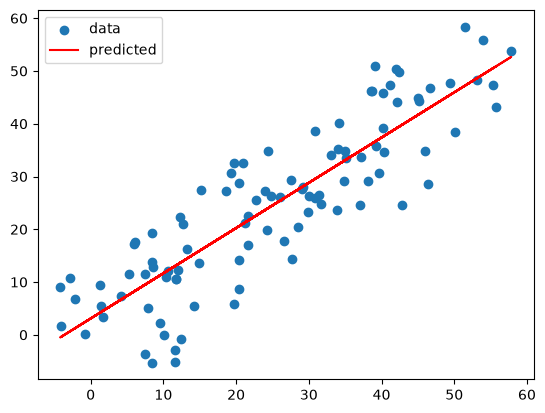

In [10]:
plt.scatter(X, y, label='data')
plt.plot(X, w_list[-1] * X + b_list[-1], 'r-', label='predicted')
plt.legend()

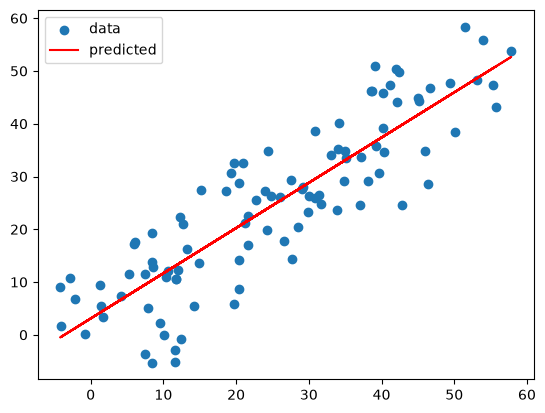

In [11]:
# NumPy 求得的迴歸線
plt.scatter(X, y, label='data')
plt.plot(X, coef[0] * X + coef[1], 'r-', label='predicted')
plt.legend()

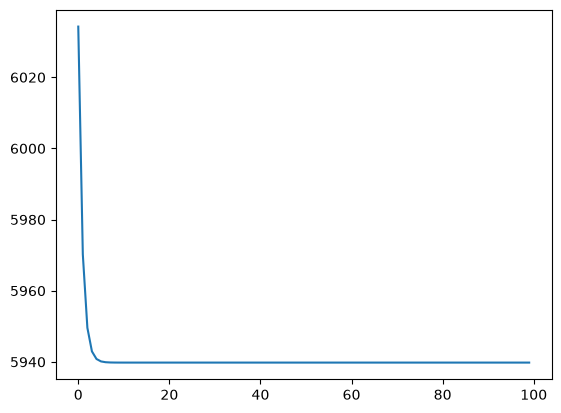

In [12]:
# 損失函數繪圖
plt.plot(loss_list)

In [13]:
loss_list

[6034.24462890625,
 5970.19384765625,
 5949.58251953125,
 5942.9501953125,
 5940.81640625,
 5940.1298828125,
 5939.9091796875,
 5939.837890625,
 5939.814453125,
 5939.8076171875,
 5939.8046875,
 5939.8037109375,
 5939.8037109375,
 5939.80419921875,
 5939.8037109375,
 5939.80419921875,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.8037109375,
 5939.803710

In [14]:
w_list

[0.9091604948043823,
 0.8867278099060059,
 0.8740027546882629,
 0.8667842745780945,
 0.8626894950866699,
 0.8603666424751282,
 0.8590490221977234,
 0.85830157995224,
 0.8578774929046631,
 0.8576370477676392,
 0.8575006127357483,
 0.8574231266975403,
 0.8573794960975647,
 0.8573545813560486,
 0.8573399782180786,
 0.8573330640792847,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.8573277592658997,
 0.857327759265

In [15]:
b_list

[1.2673572301864624,
 2.056567668914795,
 2.5042545795440674,
 2.758211374282837,
 2.9022719860076904,
 2.983992338180542,
 3.03035044670105,
 3.056645631790161,
 3.071563720703125,
 3.0800251960754395,
 3.084822654724121,
 3.0875494480133057,
 3.0890865325927734,
 3.0899622440338135,
 3.0904741287231445,
 3.090719223022461,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 3.0909059047698975,
 